In [1]:
import scipp as sc
import plopp as pp
import scippneutron as scn
import scippnexus as snx
import h5py

## An incoherent inelastic scattering simulated sample
The data file specified below contains simulated scattering from a sample with one incoherent scattering mode,
which is controlled by an instrument variable `mode_energy`.
The simulation was conducted in six steps, but we will ignore this in order to pretend that the sample has multiple flat modes:

| Parameter | Value | Notes |
|-----------|-------|-------|
| `mode_energy` / meV | \[0, 0.2, 0.4, 0.6, 0.8, 1,0] | collected stepwise, but analyzed collectively here |
| $a_3$ / degree | `None` | the sample angle was not a parameter in this simulation, so has any single value |
| $a_4$ / degree | 90. | all simulations have this single detector tank position |
| pulse-shaping chopper opening time  / msec | 0.2 | picked to be a realistic best-case energy-resolution |
| minimum $E_i$ / meV | 2.5 | giving a maximum of ~5.1 meV due to BIFROST's pseudo-white beam |

The simulation was started at approxmately 16:31 UTC on 2. September 2024.

In [2]:
datafile = "20240902/BIFROST_20240902T163047.h5"

In [3]:
from bifrost2409.config import POOCH_DATA_DIR
from bifrost2409.dataset import download_datafiles
download_datafiles([datafile])

2024-10-22 16:01:05.697 | INFO     | bifrost2409.config:<module>:13 - PROJ_ROOT path is: /home/g/Projects/20240914/bifrost-workflow-2409
Fetching: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.38it/s]


### McStas ToF versus `frame_time`

The simulated McStas events record their 'true' time-of-flight, and the Event Formation Unit does not filter too-long ToF values.
In order to emulate what will appear in _real_ files, we must convert the per-event `event_time_offset` to a time which is relative to the _last_ accelerator reference time.

This requires that we use the modulo operator, and a `transform_coords` graph to modify the per-event data.

In [4]:
def calculate_frame_time(event_time_offset):
    source_frequency = sc.scalar(14.0, unit='Hz')
    source_period = (1 / source_frequency).to(unit='ns')
    return event_time_offset % source_period

If we know the location of the object we want to examine in a NeXus file, we can access it directly:

Here, lets load the data for the first triplet in the first scattering angle wedge, `123_channel_1_1_triplet`
which is inside of the main `entry` group, within a group called `instrument`.

In [5]:
with snx.File(POOCH_DATA_DIR / datafile) as dg:
    detector = dg['entry/instrument/123_channel_1_1_triplet'][...]

detector

DataGroup(sizes={'cylinder': 1, 'vertex_index': 3, 'vertex': 3, 'dim_0': 3, 'dim_1': 100}, keys=[
    depends_on: transformations/channel_1_1_triplet_r0,
    diameter: Variable({}),
    geometry: DataGroup(2, {'cylinder': 1, 'vertex_index': 3, 'vertex': 3}),
    transformations: DataGroup(3, {}),
    type: 3 He3 tubes in series,
    x_pixel_size: Variable({}),
    y_pixel_size: Variable({}),
    data: DataArray({'dim_0': 3, 'dim_1': 100}),
])

Since the group gets loaded as a `scipp.DataGroup`, we access its members like those of a `dict`. To get the data:

In [6]:
detector['data']

<scipp.DataArray>
Dimensions: Sizes[dim_0:3, dim_1:100, ]
Coordinates:
* detector_number             int64        <no unit>  (dim_0, dim_1)  [1, 2, ..., 1899, 1900]
* x_pixel_offset            float64              [m]  (dim_0, dim_1)  [-0.014, -0.014, ..., 0.014, 0.014]
* y_pixel_offset            float64              [m]  (dim_0, dim_1)  [0.112822, 0.110543, ..., -0.110543, -0.112822]
Data:
                          DataArrayView        <no unit>  (dim_0, dim_1)  binned data: dim='event', content=DataArray(
          dims=(event: 15126),
          data=float32[counts],
          coords={'event_time_offset':int32[ns], 'event_time_zero':datetime64[ns]})

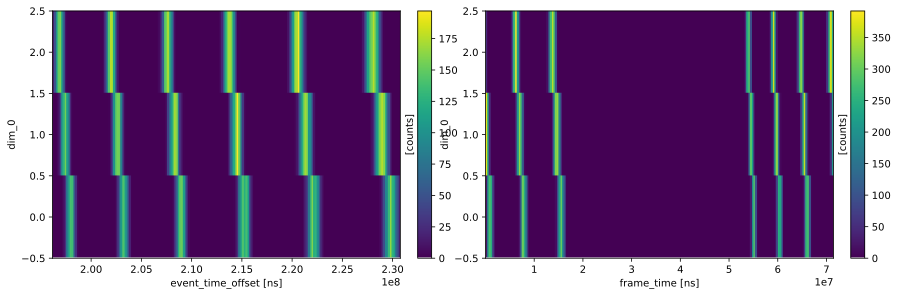

In [7]:
detector_data_with_frame_time = detector['data'].transform_coords(frame_time=calculate_frame_time)
p0 = detector_data_with_frame_time.hist(event_time_offset=200).sum('dim_1').plot()
p1 = detector_data_with_frame_time.hist(frame_time=200).sum('dim_1').plot()
p0 + p1

## Loading many groups
Knowing the locations and names of all NeXus object groups can quickly become tedious, 
so instead `scippnexus` can load all object groups that specify they are of a specific [NeXus base class](https://manual.nexusformat.org/classes/base_classes/index.html) type.

In the BIFROST simulations, all detectors are `NXdetector`, all analyzers are `NXcrystal`, all choppers are `NXdisk_chopper`, 
and all monitors are `NXmonitor`.
The following loads all such objects in the instrument group, and stores their loaded values in Python dictionaries.

In [8]:
with snx.File(POOCH_DATA_DIR / datafile) as dg:
    inst_group = dg['entry/instrument']
    triplets = {name: obj[...] for name, obj in inst_group[snx.NXdetector].items()}
    analyzers = {name: obj[...] for name, obj in inst_group[snx.NXcrystal].items()}
    choppers = {name: obj[...] for name, obj in inst_group[snx.NXdisk_chopper].items()}
    monitors = {name: obj[...] for name, obj in inst_group[snx.NXmonitor].items()}

The detectors have the same unphysical `event_time_offset` problem, plus we need to know where they're located.
We can fix both issues in one loop:

In [9]:
for name in triplets:
    triplets[name] = snx.compute_positions(triplets[name], store_transform='transform')
    triplets[name]['data'] = triplets[name]['data'].transform_coords(frame_time=calculate_frame_time)

In [10]:
triplets['127_channel_1_2_triplet']['data']

<scipp.DataArray>
Dimensions: Sizes[dim_0:3, dim_1:100, ]
Coordinates:
* detector_number             int64        <no unit>  (dim_0, dim_1)  [2701, 2702, ..., 4599, 4600]
* position                  vector3              [m]  (dim_0, dim_1)  [(0.722666, -1.30193, 0.766438), (0.724278, -1.30193, 0.764501), ..., (0.901955, -1.30578, 0.594317), (0.903567, -1.30578, 0.592379)]
* x_pixel_offset            float64              [m]  (dim_0, dim_1)  [-0.014, -0.014, ..., 0.014, 0.014]
* y_pixel_offset            float64              [m]  (dim_0, dim_1)  [0.124752, 0.122232, ..., -0.122232, -0.124752]
Data:
                          DataArrayView        <no unit>  (dim_0, dim_1)  binned data: dim='event', content=DataArray(
          dims=(event: 16701),
          data=float32[counts],
          coords={'event_time_offset':int32[ns], 'event_time_zero':datetime64[ns],
                  'frame_time':float64[ns]})

Each triplet object contains detection events for neutrons which interacted with a single analyzer.

_This is enforced with logic in the simulation, in reality the cross-talk shielding **should** enforce the same condition_

> _Note_: The NeXus format does not contain a mechanism to explicitly state neutron-path relationship
> (or, equivalently, McStas instrument component order). One could imagine using the `depends_on` chain for this,
> but a) this gets tricky to interpret before vs. after the sample (coordinate system origin)
> and b) limitations in the old NeXus Constructor or File Writer enfoced that this file has only absolute positioned components.
>

To enable automatic identification of the correct triplet analyzer pairs, the object _names_ are prefixed with an integer.
This only works as long as the order and contents of the McStas simulation do not change.

In [11]:
# The analyzer name for each detector has a number two less at the start of its name:
d2a_name = {d: [x for x in analyzers.keys() if x.startswith(str(int(d.split('_',1)[0])-2))][0] for d in list(triplets.keys())}

We also need to find the triplet object name for each pixel number

In [12]:
# Map pixel index to physical detector name
p2d = {i: d for d in list(triplets.keys()) for i in triplets[d]['data'].coords['detector_number'].values.flatten()}

Compute the position (and orientation) of each analyzer, then combine a subset of their properties and duplicate that to have per-pixel analyzer information.

In [13]:
def analyzer_extract(obj):
    obj = snx.compute_positions(obj, store_transform='transform')
    return sc.Dataset(data={k: obj[k] for k in ('position', 'transform', 'd_spacing')})

analyzer_extracted = {k: analyzer_extract(v) for k, v in analyzers.items()}
p2a_extract = {k: analyzer_extracted[d2a_name[v]] for k, v in p2d.items()}
# by sorting the pixel indices, we ensure a one-to-one match with detector information
pixels = sorted(p2a_extract)
analyzers = sc.concat([p2a_extract[p] for p in pixels], dim='event_id')
analyzers['event_id'] = sc.array(values=pixels, dims=['event_id'], unit=None)

The same can be done for the detectors, to have per-pixel detector information

In [14]:
def detector_extract(name, obj):
    pixel_indices = obj['data'].coords['detector_number']
    cyl_midpoints = obj['data'].coords['position']
    
    return sc.Dataset(data={'event_id': pixel_indices, 'position': cyl_midpoints})

detector_extracted = {k: detector_extract(k, v) for k, v in triplets.items()}
detectors = sc.concat(list(detector_extracted.values()), dim='arm')
detectors = sc.Dataset({k: v.flatten(to='event_id') for k, v in detectors.items()})
detectors = sc.sort(detectors, detectors['event_id'].data)

## We can see all events for all pixels

As a function of simulation runtime (equivalent to measurement time) -- here we show _how_ the simulation was performed to emulate a multi-level system.

Knowing that `mode_energy` was 0 meV, then 0.2 meV, ...,  to 1.0 meV as a function of simulation time:

**Can you identify the inter-frame pivot time from this data alone?**

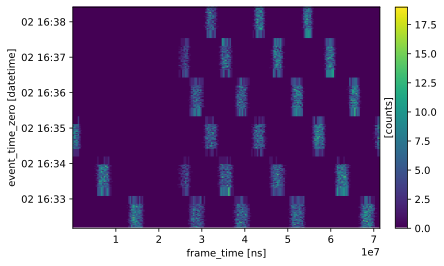

In [15]:
all_events = sc.concat([v['data'] for v in triplets.values()], 'event_time_zero').bins.concat().group('event_time_zero')
all_events.hist(frame_time=200).plot()

Or integrated over the measurement time

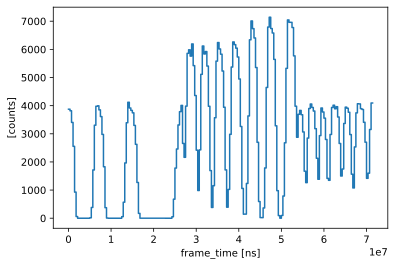

In [16]:
all_events.hist(frame_time=200).sum('event_time_zero').plot()

## To identify the time-of-flight we must back-propagate the events
The sample-to-detector flight time is fixed per pixel, so we can find the frame time for each event when the neutron interacted with the sample.
This requires that we use part of the workflow, and `sciline`

In [17]:
from sciline import Pipeline
import numpy as np
from ess.spectroscopy.types import *
from ess.spectroscopy.indirect.kf import providers as kf_providers

The sample _should_ be at (0, 0, 0), but we use its recorded position in case it is not.
Then we collect parameters needed to find the per-pixel sample-to-detector times, 
and construct the graph that can perform the calculation

In [18]:
with snx.File(POOCH_DATA_DIR / datafile) as dg:
    sample = snx.compute_positions(dg['entry/instrument/114_sample_stack'][...], store_transform='transform')

geometry_params = {
    SamplePosition: sample['position'],
    AnalyzerPosition: analyzers['position'].data,
    AnalyzerOrientation: analyzers['transform'].data,
    DetectorPosition: detectors['position'].data,
    ReciprocalLatticeSpacing: 2 * np.pi / analyzers['d_spacing'].data,
}
sample_detector_flight_time_pipeline = Pipeline(kf_providers, params=geometry_params)

In [19]:
sample_detector_flight_times = sample_detector_flight_time_pipeline.get(SampleDetectorFlightTime).compute().to(unit='ms')

Collect the events for all triplets, sorted by pixel index; then perform the back-propagation


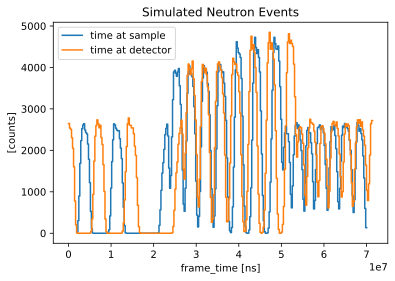

In [20]:
triplet_events = sc.concat([v['data'] for v in triplets.values()], dim='a').flatten(to='event_id')
triplet_events = sc.sort(triplet_events, triplet_events.coords['detector_number'])

sample_events = triplet_events.copy()
for coord in ('position', 'x_pixel_offset', 'y_pixel_offset'):
    del sample_events.coords[coord]
sample_events.bins.coords['frame_time'] -= sample_detector_flight_times.to(unit='ns')
sample_events.bins.coords['frame_time'] %= (1/sc.scalar(14.0, unit='Hz')).to(unit='ns')

pp.plot({
    'time at sample': sample_events.bins.concat().hist(frame_time=300), 
    'time at detector': triplet_events.bins.concat().hist(frame_time=300)
}, title="Simulated Neutron Events")

### Now use the primary spectrometer to find the likely time-of-flight per event

In [21]:
from ess.spectroscopy.indirect.ki import providers as ki_providers
primary_params = {
    NeXusFileName: POOCH_DATA_DIR / datafile,
    SampleName: '114_sample_stack',
    SourceName: '001_ESS_source',
    SourceDelay: sc.array(values=[0, 0], dims=['wavelength'], unit='sec'),  # moderator emission delay
    SourceDuration: sc.scalar(3.0, unit='msec').to(unit='sec'),
    SourceFrequency: sc.scalar(14.0, unit='Hz'),
    SourceVelocities: sc.array(values=[100, 1e4], dims=['wavelength'], unit='m/s'), # ~53 ueV to 530 meV
    SampleFrameTime: sample_events.data.bins.coords['frame_time'],
    FocusComponentNames: [FocusComponentName('005_PulseShapingChopper'), FocusComponentName('006_PulseShapingChopper2')],
}
primary_pipeline = Pipeline(ki_providers, params=primary_params)

In [22]:
unwrapped_sample_events = sample_events.copy()
unwrapped_sample_events.bins.coords['frame_time'] = primary_pipeline.get(SampleTime).compute()

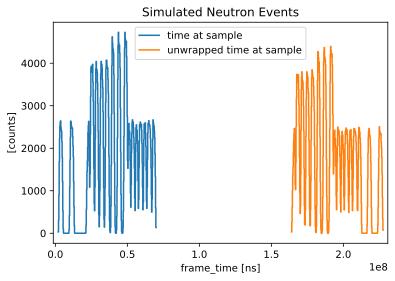

In [23]:
pp.plot({
    'time at sample': sample_events.bins.concat().hist(frame_time=300), 
    'unwrapped time at sample': unwrapped_sample_events.bins.concat().hist(frame_time=300),
}, title="Simulated Neutron Events")

The unwrapped sample time minus the pulse shaping chopper focus time gives the primary-spectrometer time-of-flight, and incident energy.
We can verify that this has been done correctly by propagating the unwrapped times to the detectors, and comparing with the McStas recorded time-of-flights:

In [24]:
mcstas_events = triplet_events.copy()
del mcstas_events.bins.coords['frame_time'] # otherwise we can't rename event_time_zero

total_flight_time_events = unwrapped_sample_events.copy()
total_flight_time_events.bins.coords['frame_time'] += sample_detector_flight_times.to(unit='ns')

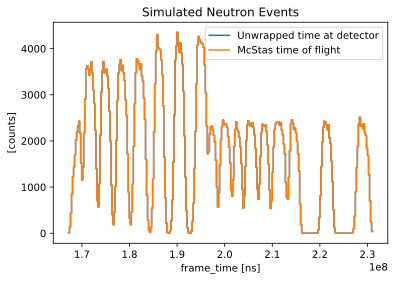

In [25]:
pp.plot({
    'Unwrapped time at detector': total_flight_time_events.bins.concat().hist(frame_time=300),
    'McStas time of flight': mcstas_events.transform_coords(frame_time='event_time_offset').bins.concat().hist(frame_time=300),
}, title="Simulated Neutron Events")

## Convert from times to energies

In [26]:
from ess.spectroscopy.indirect.conservation import providers as qe_providers
qe_params = dict()
qe_params.update(primary_params)
qe_params.update(geometry_params)
qe_pipeline = Pipeline(qe_providers, params=qe_params)

energy_events = sample_events.copy()
energy_events.bins.coords['energy_transfer'] = qe_pipeline.get(EnergyTransfer).compute().to(unit='meV')
energy_events.bins.coords['incident_energy'] = qe_pipeline.get(IncidentEnergy).compute()

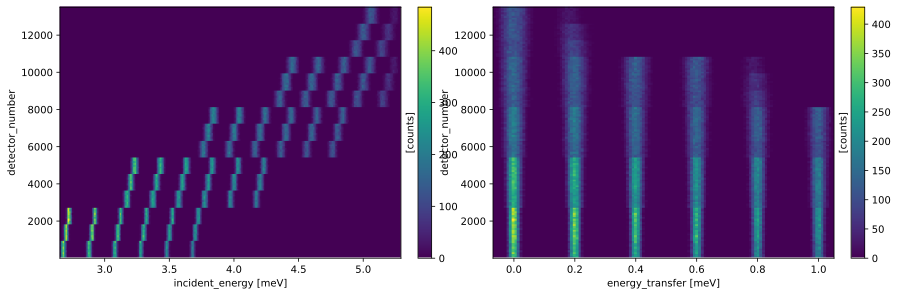

In [27]:
tube_count = 3 * 9 * 5
p0 = energy_events.hist(detector_number=tube_count, incident_energy=256).plot()
p1 = energy_events.hist(detector_number=tube_count, energy_transfer=128).plot()
p0 + p1